In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats
import re

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "grw_global", "ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "grw_global": "GRW-G", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "ar1_s_globalinit": "AR(1)-GRW-S-G", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "grw_global": "#8C564B", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "ar1_s_globalinit": "#17BECF", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]

def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate

def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)

def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [6]:
AR_MODELS = ["ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
PARAMETER_FILES = {"ar1_y": "yearwise-parameters.csv", "ar1_s": "stagewise-parameters.csv", "ar1_s_globalinit": "stagewise-parameters.csv", "hurdle_ar1_s": "stagewise-positive-ar1-parameters.csv", "hurdle_ar1_s_p": "stagewise-positive-ar1-parameters.csv", "hurdle_ar3_s_p": "stagewise-positive-ar3-parameters.csv"}

def read_params(tag):
    path = SIMULATE / tag / "parameters" / PARAMETER_FILES[tag]
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def expand_params(tag, frame):
    if "transition_year" in frame.columns:
        out = frame.rename(columns={"transition_year": "year"}).copy()
    else:
        rows = []
        for row in frame.to_dict("records"):
            end_col = "transition_year_end" if "transition_year_end" in row else "transition_year_end_inclusive"
            rows += [{"year": year, **row} for year in range(int(row["transition_year_start"]), int(row[end_col]) + 1)]
        out = pd.DataFrame(rows)
    beta_cols = sorted([c for c in out.columns if re.fullmatch(r"beta_\d+", c)], key=lambda c: int(c.split("_")[1]))
    if "beta" in out.columns:
        beta_cols = ["beta"]
    out["persistence"] = out["spectral_radius"] if tag == "hurdle_ar3_s_p" else out[beta_cols[0]]
    out["model_tag"] = tag
    out["model"] = MODEL_NAMES[tag]
    return out, beta_cols

parameter_frames, beta_columns = {}, {}
for tag in AR_MODELS:
    parameter_frames[tag], beta_columns[tag] = expand_params(tag, read_params(tag))
parameter_trajectories = pd.concat(parameter_frames.values(), ignore_index=True, sort=False)
parameter_trajectories.to_csv(RESULTS / "autoregressive-parameter-trajectories.csv", index=False)
display(parameter_trajectories.head())


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid,...,model_tag,model,stage,transition_year_start,transition_year_end,spectral_radius,is_stationary,beta_1,beta_2,beta_3
0,0,1963,0.979817,0.402023,0.936911,0.877802,1.638552,1.047024,-2.624266e-17,0.936911,...,ar1_y,AR(1)-GRW-Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2003,0.928713,0.484905,0.875755,0.766947,1.802994,1.002720,4.394333e-16,0.875755,...,ar1_y,AR(1)-GRW-Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2005,0.835426,0.534576,0.850810,0.723878,1.794980,1.013511,-6.378937e-17,0.850810,...,ar1_y,AR(1)-GRW-Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1944,0.845369,0.535518,0.848332,0.719667,1.820026,1.009039,-1.135808e-15,0.848332,...,ar1_y,AR(1)-GRW-Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1874,0.745726,0.545489,0.847330,0.717968,1.640721,1.022104,1.251223e-16,0.847330,...,ar1_y,AR(1)-GRW-Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


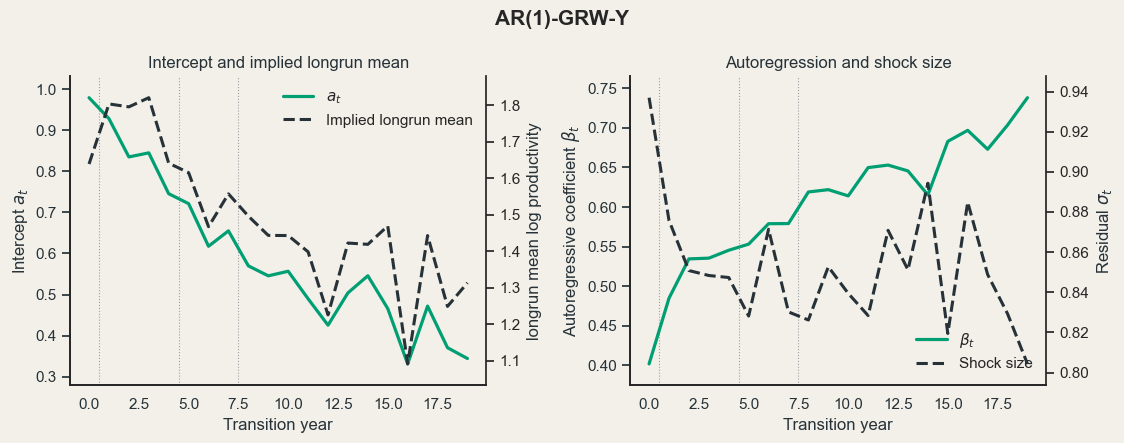

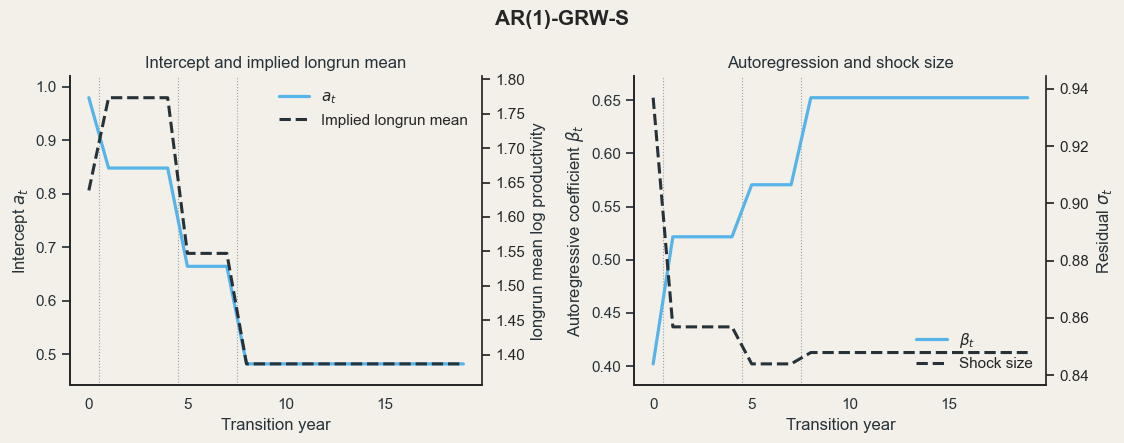

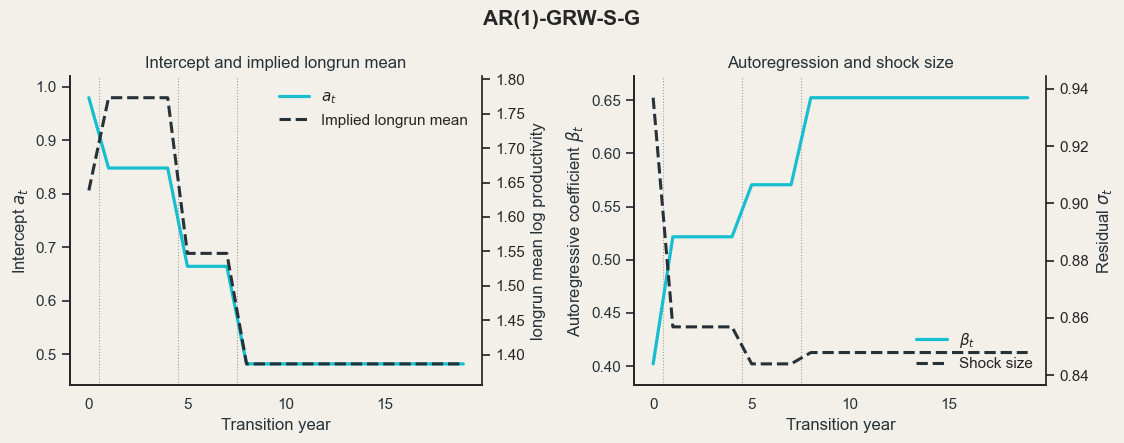

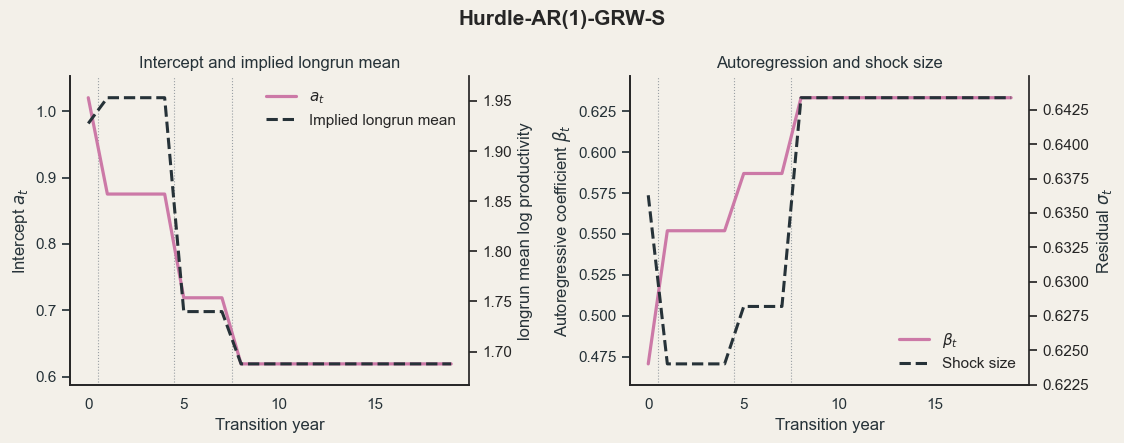

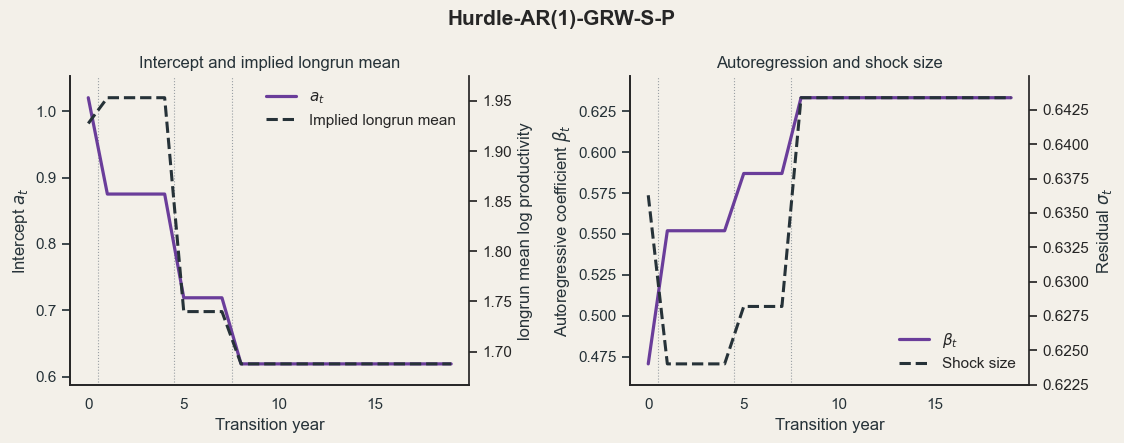

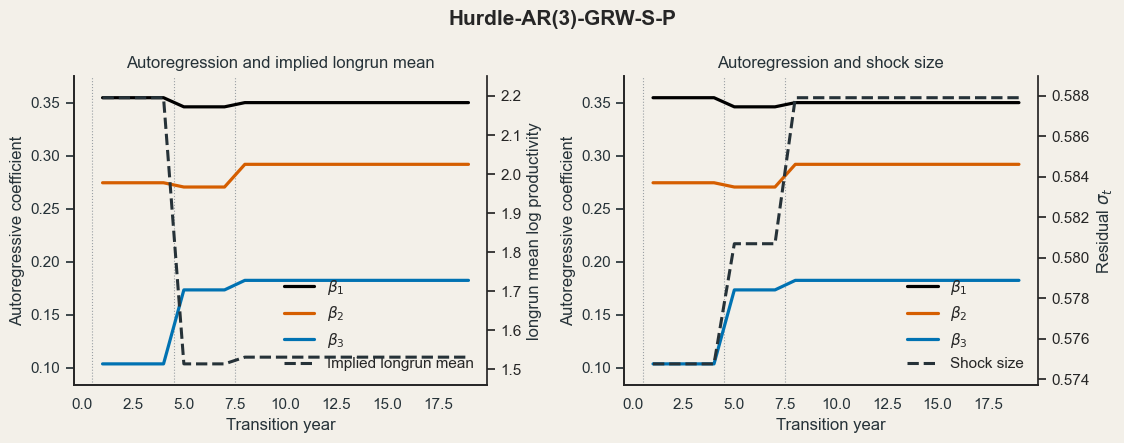

In [7]:
AR1_MODELS = ["ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p"]

def padded(values, fraction=0.08):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        return (-1, 1)
    lo, hi = values.min(), values.max()
    span = hi - lo
    pad = fraction * (span if span > 0 else max(abs(lo), 1))
    return (lo - pad, hi + pad)

def draw_line(ax, frame, column, color, label, ylabel):
    lines = ax.plot(frame["year"], frame[column], color=color, lw=2.3, label=label)
    ax.set_ylim(*padded(frame[column]))
    ax.set_ylabel(ylabel)
    return lines

def draw_betas(ax, tag, frame):
    lines = []
    palette = [MODEL_COLORS[tag], "#D55E00", "#0072B2"]
    for i, column in enumerate(beta_columns[tag]):
        label = r"$\beta_t$" if column == "beta" else rf"$\beta_{{{column.split('_')[1]}}}$"
        lines += ax.plot(frame["year"], frame[column], color=palette[i], lw=2.3, label=label)
    ax.set_ylim(*padded(frame[beta_columns[tag]].stack()))
    ax.set_ylabel("Autoregressive coefficient")
    return lines

def configure_twin(ax):
    twin = ax.twinx()
    style_axis(ax, stages=True)
    twin.set_facecolor("none")
    twin.spines["top"].set_visible(False)
    return twin

def combined_legend(ax, primary, secondary):
    lines = primary + secondary
    ax.legend(lines, [line.get_label() for line in lines], frameon=False)

def plot_model(tag):
    frame = parameter_frames[tag]
    fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))
    fig.patch.set_facecolor(PAPER_BG)
    ax = axes[0]
    twin = configure_twin(ax)
    if tag in AR1_MODELS:
        primary = draw_line(ax, frame, "intercept", MODEL_COLORS[tag], r"$a_t$", r"Intercept $a_t$")
        title = "Intercept and implied longrun mean"
    else:
        primary = draw_betas(ax, tag, frame)
        title = "Autoregression and implied longrun mean"
    mean_line = twin.plot(frame["year"], frame["implied_stationary_mean_log"], color=INK, lw=2.2, ls="--", label="Implied longrun mean")
    twin.set_ylim(*padded(frame["implied_stationary_mean_log"]))
    twin.set_ylabel("longrun mean log productivity", color=INK)
    ax.set(title=title, xlabel="Transition year")
    combined_legend(ax, primary, mean_line)

    ax = axes[1]
    twin = configure_twin(ax)
    primary = draw_line(ax, frame, "beta", MODEL_COLORS[tag], r"$\beta_t$", r"Autoregressive coefficient $\beta_t$") if tag in AR1_MODELS else draw_betas(ax, tag, frame)
    shock_line = twin.plot(frame["year"], frame["sigma_resid"], color=INK, lw=2.2, ls="--", label="Shock size")
    twin.set_ylim(*padded(frame["sigma_resid"]))
    twin.set_ylabel(r"Residual $\sigma_t$", color=INK)
    ax.set(title="Autoregression and shock size", xlabel="Transition year")
    combined_legend(ax, primary, shock_line)

    fig.suptitle(MODEL_NAMES[tag], fontsize=15, fontweight="bold")
    fig.tight_layout()
    savefig(fig, f"autoregressive_parameters_{tag}.png")
    plt.show()


for tag in AR_MODELS:
    plot_model(tag)


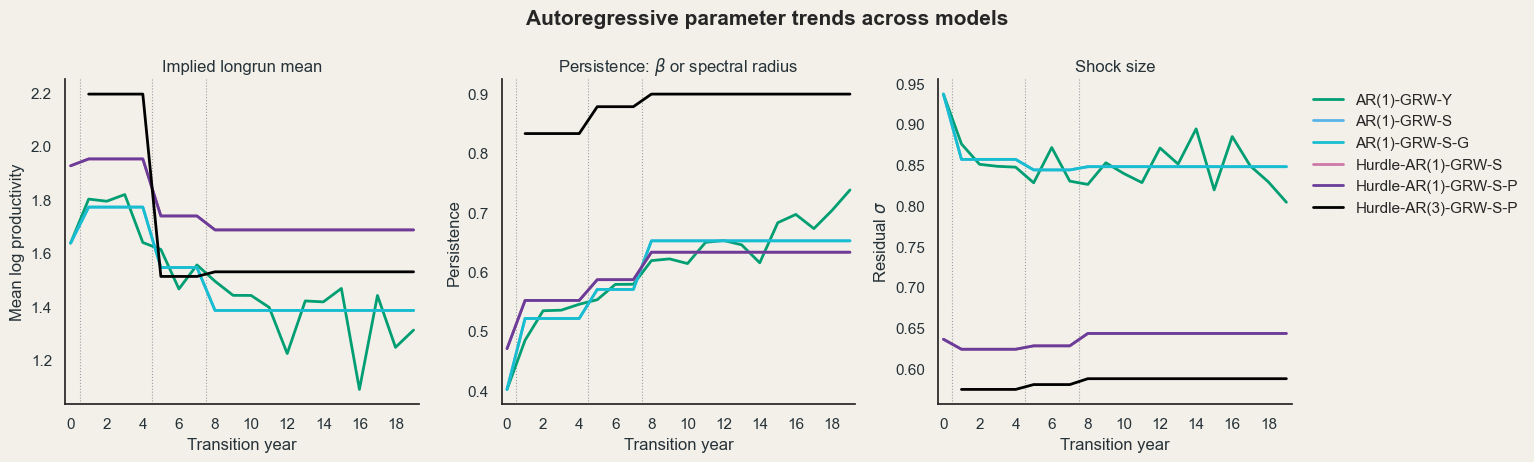

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7), sharex=True)
fig.patch.set_facecolor(PAPER_BG)
for ax in axes:
    style_axis(ax, stages=True)
    ax.set_xlim(-0.3, Y - 0.7)
    ax.set_xticks(np.arange(0, Y, 2))
    ax.set_xlabel("Transition year")
for tag in AR_MODELS:
    frame = parameter_frames[tag]
    axes[0].plot(frame["year"], frame["implied_stationary_mean_log"], color=MODEL_COLORS[tag], lw=2, label=MODEL_NAMES[tag])
    axes[1].plot(frame["year"], frame["persistence"], color=MODEL_COLORS[tag], lw=2, label=MODEL_NAMES[tag])
    axes[2].plot(frame["year"], frame["sigma_resid"], color=MODEL_COLORS[tag], lw=2, label=MODEL_NAMES[tag])
axes[0].set_title("Implied longrun mean")
axes[0].set_ylabel("Mean log productivity")
axes[1].set_title(r"Persistence: $\beta$ or spectral radius")
axes[1].set_ylabel("Persistence")
axes[2].set_title("Shock size")
axes[2].set_ylabel(r"Residual $\sigma$")
axes[2].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Autoregressive parameter trends across models", fontsize=15, fontweight="bold")
fig.tight_layout()
savefig(fig, "autoregressive_parameters_all_models.png")
plt.show()